## 3. 无重复字符的最长子串

给定一个字符串 s ，请你找出其中不含有重复字符的 最长 子串 的长度。

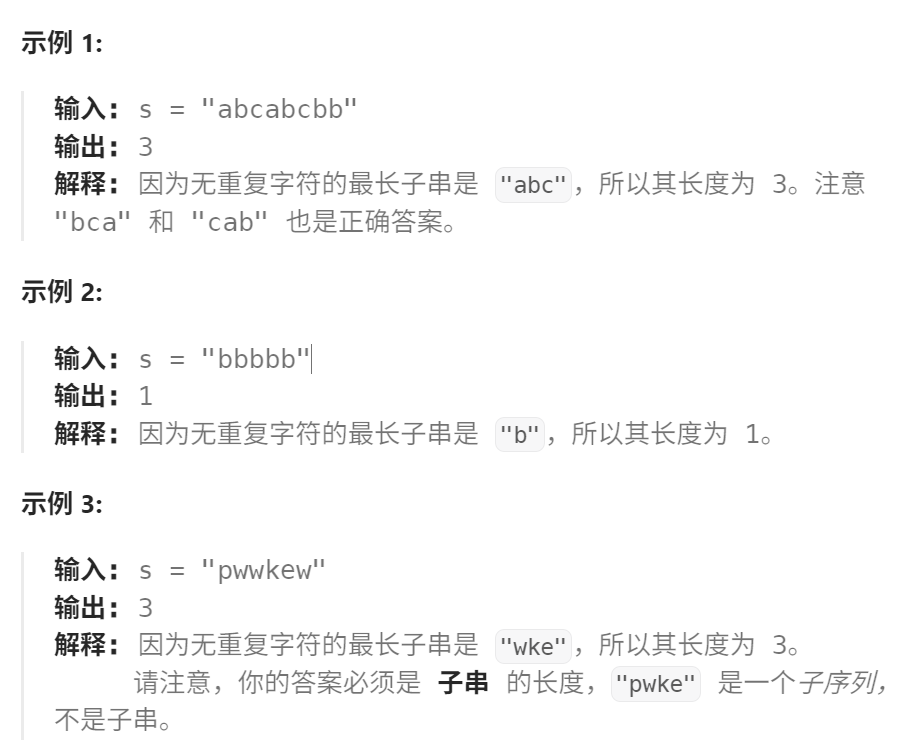

核心思路：采用滑动窗口思想，用左右指针维护一个不包含重复字符的区间，并通过哈希集合实时记录窗口内已出现的字符；当右指针加入的新字符发生重复时，持续移动左指针并删除对应字符，直到窗口重新满足“无重复”的条件，同时在遍历过程中更新窗口的最大长度

In [14]:
class Solution:
    def lengthOfLongestSubstring(self, s: str) -> int:
        max_len = 0
        hashtable = set()
        # 左指针，代表当前窗口的起始位置
        l = 0
        for r, ch in enumerate(s):
            while ch in hashtable:
                # 如果当前字符已经在哈希表中，则将左指针位置的字符从哈希表中移除，并将左指针右移
                hashtable.remove(s[l])
                l += 1
            hashtable.add(ch)
            # 最大长度 = max(当前最大长度, 当前窗口长度r-l+1)
            max_len = max(max_len, r-l+1)
        return max_len
str1 = "abcabcbb"
print(Solution().lengthOfLongestSubstring(str1))

3


复杂度分析

由于每个字符最多被加入和移除集合各一次，整体仅进行一次线性扫描，时间复杂度为 O(n)；哈希集合中最多存放不重复字符，空间占用与字符集大小或字符串长度成正比，故空间复杂度为 O(n)

---

## 438. 找到字符串中所有字母异位词

给定两个字符串 s 和 p，找到 s 中所有 p 的 异位词 的子串，返回这些子串的起始索引。不考虑答案输出的顺序。
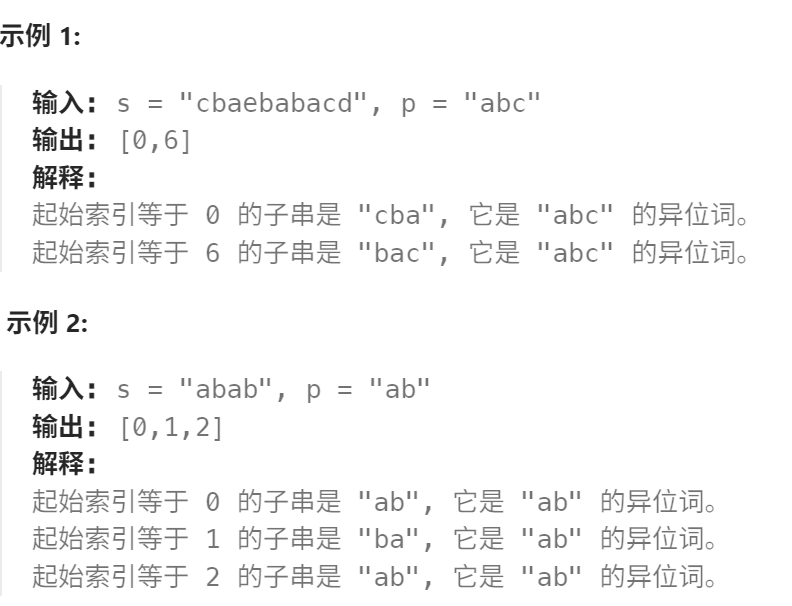

核心思路：

因为字符串 p 的异位词的长度一定与字符串 p 的长度相同，所以我们可以在字符串 s 中构造一个长度为与字符串 p 的长度相同的滑动窗口，并在滑动中维护窗口中每种字母的数量；当窗口中每种字母的数量与字符串 p 中每种字母的数量相同时，则说明当前窗口为字符串 p 的异位词。


In [15]:
from typing import List
class Solution:
    def findAnagrams(self, s: str, p: str) -> List[int]:
        n, m = len(s), len(p)
        # target统计字符串 p 中每个字母的数量，window统计s滑动窗口中每个字母的数量
        target = [0] * 26
        window = [0] * 26
        ans = []
        if n < m:
            return []
        # 初始化target和window,其中window先统计s的前m个字符，如果初始化相等，则直接将索引0加入结果
        for ch in p:
            target[ord(ch) - 97] += 1
        for i in range(m) :
            ch = s[i]
            window[ord(ch)-  97] += 1
        if target == window:
            ans.append(0)

        # 从s的第m个字符开始滑动窗口，每次移动都更新window中对应字母的数量
        for right_i in range(m, n):
            # 左侧滑动窗口的索引为right_i - m，右侧滑动窗口的索引为right_i，相差m个位置
            left_i = right_i - m
            right_ch = s[right_i]
            left_ch = s[left_i]
            # 更新window中对应字母的数量，左侧滑动窗口的字母数量减1，右侧滑动窗口的字母数量加1
            window[ord(left_ch) - 97] -= 1
            window[ord(right_ch) - 97] += 1

            # 若更新后的window与target相等，则将更新后的窗口的起始索引left_ch + 1加入结果
            if target == window:
                ans.append(left_i + 1)

        return ans
str1 = "cbaebabacd"
str2 = "abc"
print(Solution().findAnagrams(str1, str2))

[0, 6]


**复杂度分析：**

该算法基于固定长度的滑动窗口。首先对字符串 `p` 和 `s` 的前 m 个字符进行一次统计初始化，时间复杂度为 O(m)；随后窗口在字符串 `s` 上从左到右滑动，每次滑动只涉及常数次字符计数的增减操作，并比较两个长度为 26 的计数数组。由于窗口一共滑动 n−m 次，且每次比较数组的代价为 O(26)，可视为常数，因此整体**时间复杂度为 O(n)**，其中 n 是字符串 `s` 的长度。

空间复杂度方面，算法使用了两个长度固定为 26 的计数数组 `target` 和 `window`，以及结果列表 `ans`。计数数组占用常数空间，结果列表在最坏情况下可能存储 O(n) 个索引。因此，**额外空间复杂度为 O(n)**（若不计输出结果，仅辅助空间为 O(1)）。

---

版本2：用哈希表维护状态；

字典版的额外优势是不限于小写字母，若输入包含大写、数字或 Unicode，数组版需要大改，字典版无需改动。

但需要注意，字典版需要删除频次为0的键值，如果不删除 0 值键，窗口里会残留无意义的 {'b': 0} 这类条目，导致比较失败。

In [4]:
from typing import List
from collections import Counter

class Solution:
    def findAnagrams(self, s: str, p: str) -> List[int]:
        n, m = len(s), len(p)
        ans = []

        if n < m:
            return []

        target = Counter(p)                # p 的字符频次
        window = Counter(s[:m])            # 初始窗口

        if window == target:
            ans.append(0)

        for right_i in range(m, n):
            left_i = right_i - m
            right_ch = s[right_i]
            left_ch = s[left_i]
            # 右侧新字符加入窗口
            window[right_ch] += 1
            # 左侧旧字符移出窗口
            window[left_ch] -= 1
            if window[left_ch] == 0:
                del window[left_ch]        # ← 关键：删除 0 值键

            if window == target:
                ans.append(left_i + 1)

        return ans
str1 = "cbaebabacd"
str2 = "abc"
print(Solution().findAnagrams(str1, str2))

[0, 6]


---

## 239. 滑动窗口最大值

给你一个整数数组 nums，有一个大小为 k 的滑动窗口从数组的最左侧移动到数组的最右侧。你只可以看到在滑动窗口内的 k 个数字。滑动窗口每次只向右移动一位。
返回 滑动窗口中的最大值 。

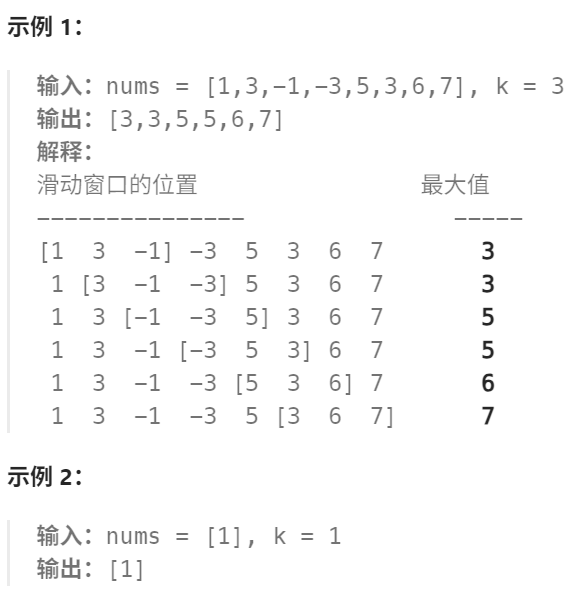


核心思路：
维护一个单调递减的双端队列，队列中存的是数组下标，对应的值从队头到队尾递减。

队头始终保存当前窗口内的最大值下标

新元素进入窗口时，持续弹出队尾中所有比它小的元素（它们不可能再成为最大值）

窗口左端滑出时，若队头下标已不在窗口内，则弹出队头

当窗口形成（索引 ≥ k−1）后，队头元素即为当前窗口最大值

该方法保证每个元素最多进队一次、出队一次。


In [17]:
from collections import deque
from typing import List

class Solution:
    def maxSlidingWindow(self, nums: List[int], k: int) -> List[int]:

        q = deque()   # 存下标，保持 nums[q] 单调递减
        res = []

        for i, x in enumerate(nums):
            # 1. 维护单调性：弹出所有比当前值小的元素
            while q and nums[q[-1]] <= x:
                q.pop()

            q.append(i)

            # 2. 移除窗口外的元素，此时遍历到元素索引i，则该窗口最左侧值索引为i-k+1，所以需要排除掉小于等于i-k的元素
            if q[0] < i - k + 1:
                q.popleft()

            # 3. 窗口形成后，记录最大值
            if i >= k - 1:
                res.append(nums[q[0]])

        return res

nums = [1,3,-1,-3,5,3,6,7]
k = 3
s = Solution()
print(s.maxSlidingWindow(nums, k))

[3, 3, 5, 5, 6, 7]


复杂度分析

时间复杂度：O(n)
每个元素最多入队一次、出队一次，整体为线性复杂度。

空间复杂度：O(k)
队列中最多存放 k 个元素的下标。

---

## 76. 最小覆盖子串

给定两个字符串 s 和 t，长度分别是 m 和 n，返回 s 中的 最短窗口 子串，使得该子串包含 t 中的每一个字符（包括重复字符）。如果没有这样的子串，返回空字符串 ""。

测试用例保证答案唯一。

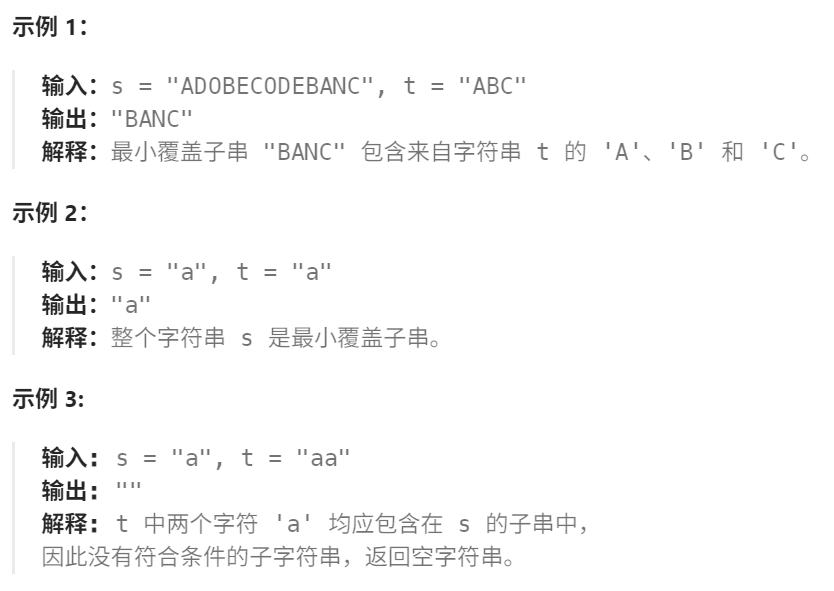

核心思路说明：
使用左右指针在字符串 s 上维护一个可变长度的窗口，用两个计数结构分别记录：
1）need：字符串 t 中每个字符所需的次数；
2）window：当前窗口中各字符出现的次数。

右指针不断右移以扩展窗口，当窗口已经覆盖了 t 的全部需求（即所有字符次数均满足）时，开始移动左指针收缩窗口，在保持覆盖条件成立的前提下不断缩短长度，并更新最短答案。

In [3]:
from collections import Counter
import collections

class Solution:
    def minWindow(self, s: str, t: str) -> str:
        # --- 边界情况 ---
        # 若任一字符串为空，不可能存在覆盖子串
        if not s or not t:
            return ""

        # need: 记录目标字符串 t 中每个字符需要的次数
        # 例如 t = "AABC" -> {'A':2, 'B':1, 'C':1}
        need = Counter(t)

        # window: 当前滑动窗口中各字符出现次数
        window = collections.defaultdict(int)

        # valid: 当前窗口中“满足次数要求的字符种类数”
        # 注意：统计的是“种类”，不是总字符数
        valid = 0

        # left: 滑动窗口左边界
        left = 0

        # start: 记录最小覆盖子串的起始位置
        start = 0

        # min_len: 记录当前找到的最小覆盖子串长度
        min_len = float('inf')

        # --- 扩张窗口 ---
        # right 指针不断右移
        for right, ch in enumerate(s):

            # 只有当当前字符是目标字符时才需要处理
            if ch in need:
                # 更新窗口内字符频次
                window[ch] += 1

                # 若该字符频次“刚好达到”需求次数
                # 说明该字符种类已经满足要求
                if window[ch] == need[ch]:
                    valid += 1

            # --- 收缩窗口 ---
            # 当窗口已经满足所有字符种类需求时
            # valid == len(need) 表示所有字符都满足
            while valid == len(need):

                # 更新最小覆盖子串
                if right - left + 1 < min_len:
                    min_len = right - left + 1
                    start = left

                # 准备移除左侧字符
                d = s[left]
                left += 1

                # 如果移除的是目标字符，才会影响窗口合法性
                if d in need:

                    # 如果当前字符数量“刚好等于需求”
                    # 那么移除后将变成不满足
                    if window[d] == need[d]:
                        valid -= 1

                    # 更新窗口字符数量
                    window[d] -= 1

        # 若 min_len 未更新，说明不存在覆盖子串
        return "" if min_len == float('inf') else s[start:start + min_len]


# 示例
s = "ADOBECODEBANC"
t = "ABC"
print(Solution().minWindow(s, t))

BANC


In [19]:
class Solution:
    def minWindow(self, s: str, t: str) -> str:
        need = {}
        for i in t:
            need[i] = need.get(i, 0) + 1
        window = {}

        valid = 0
        require = len(need)

        start, left = 0, 0
        n = len(s)
        min_len = n+1
        for right, val in enumerate(s):
            if val in need:
                window[val] = window.get(val, 0) + 1
                if window[val] == need[val]:
                    valid += 1
            while valid == require:
                cur_len = right-left+1
                if cur_len < min_len:
                    min_len = cur_len
                    start = left

                d = s[left]
                left += 1
                
                if d in need:
                    if window[d] == need[d]:
                        valid -= 1
                    window[d] -= 1            
        return s[start:start+min_len] if min_len != n+1 else ""

s = "ADOBECODEBANC"
t = "ABC"
print(Solution().minWindow(s, t))


BANC


复杂度分析

时间复杂度：O(m)
左右指针各自最多遍历字符串 s 一次，所有操作均为常数时间。

空间复杂度：O(n)
主要来自 need 和 window 两个计数哈希表，其大小与字符串 t 中不同字符数成正比。

---